## 요약
- 기존 전처리 코드에서는 정수 인코딩한 token들도 scaling을 진행함
- transformer에서 embedding model을 사용하려면 정수 값으로 입력 받아야 함
- 또한 중고 도서 데이터가 아닌 도서 정보만 사용
- 이에 맞게 코드 수정

In [1]:
import os, natsort, re
from tqdm import tqdm
import time, random

In [2]:
from itertools import repeat, chain

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_squared_log_error as msle

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png2x")
# 테마 설정: "default", "classic", "dark_background", "fivethirtyeight", "seaborn"
mpl.style.use("fivethirtyeight")
# 이미지가 레이아웃 안으로 들어오도록 함
mpl.rcParams.update({"figure.constrained_layout.use": True})
mpl.rcParams['axes.unicode_minus'] = False

In [3]:
from google.colab import drive

drive.mount('/content/drive/', force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
#cd /content/drive/MyDrive/AI3_prjct2_aladin/

In [ ]:
cd /content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/

[Errno 2] No such file or directory: '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/research


In [4]:
# 로컬에서

plt.rc("font", family = "D2Coding")
plt.rcParams["axes.unicode_minus"] = False

In [5]:
PRJCT_PATH = '/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/'
#PRJCT_PATH = '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
#PRJCT_PATH = '/content/drive/MyDrive/AI3_prjct2_aladin/aladin_usedbook/'
save_dir = 'processed/model_input'
dir_path = os.path.join(PRJCT_PATH,save_dir)
#dir_path = './'

In [6]:
dir_path

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/model_input'

In [7]:
import sys
sys.path.append(PRJCT_PATH)

In [8]:
RSLT_DIR = PRJCT_PATH + 'processed/'

bookinfo_name = 'bookinfo_ver{}_single.csv'.format(2.0)
bookinfo_path = os.path.join(RSLT_DIR,bookinfo_name)

sys.path.append(PRJCT_PATH)
from module_aladin.file_io import load_pkl, save_pkl
from module_aladin.data_process import pd_datetime_2_datenum

import itertools

In [9]:
def set_corpus_size(freq,size_feat,mode):
    # 입력받은 mode와 size_feat에 따라 size 크기 결정
    if mode == 'uniform':
        cond = freq['counts']>=freq['counts'].iloc[size_feat]
        size = np.sum(cond)
    elif mode =='ths':
        cond = freq[freq['counts'] > size_feat]
        size = np.sum(cond)
    else :
        if size_feat == None : size = len(freq)
#        elif size_feat > len(data) : size = len(freq)
        else : size = size_feat
    return size

def make_encoding_by_freq(freq,null_val='[PAD]',size_feat=None,mode=None):
    #빈도수 기반 정수 인코딩 dict 만들기
    # freq : token 별 등장 빈도 (value_count), size_feat : size관련 변수(max_size, ths등), mode : size 결정 방법
    df_freq = pd.DataFrame(freq).T
    df_freq = df_freq.rename(columns={0:'token',1:'counts'})
    temp = df_freq.sort_values(by='counts',ascending=False)
    size = set_corpus_size(temp,size_feat,mode)
    temp = temp.iloc[:size]
    temp['val'] = np.arange(size)+1
    temp2 = temp.set_index('token').to_dict()
    map_token_encode = temp2['val']
    map_token_encode[null_val]=0
    return map_token_encode

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0 
    return map_token[x] if x in map_token else oov_val

def make_author_encode_map(bookinfo,ths_author):
    pvtb = pd.pivot_table(data=bookinfo,index='Author',values='SalesPoint',aggfunc=np.sum)
    pvtb = pvtb.sort_values(by='SalesPoint',ascending=False)
    author_top_k= pvtb[pvtb['SalesPoint']>=ths_author].index
    encode_author = pd.DataFrame({'author' : author_top_k.values,'val':np.arange(1,len(author_top_k)+1)})
    encode_author = encode_author.set_index('author')
    return encode_author.to_dict()['val']

def make_publshr_encode_map(publshr_data,ths_publshr):
    stats = publshr_data.value_counts().sort_values(ascending=False)
    top_k_val = stats.iloc[ths_publshr]
    publshr_top_k = list(stats[stats >= top_k_val].index)
    return {
        publshr : n+1
        for n,publshr in enumerate(publshr_top_k)
    }
    

def make_store_encode_map(store_data):
    stores= store_data.value_counts().sort_values(ascending=False)
    return {
        place : n+1
        for n,place in enumerate(stores.index)
    }

In [10]:
#file_name = 'bookinfo_ver{}.csv'.format(1.0)
#file_path = os.path.join(RSLT_DIR,file_name)
bookinfo_raw = pd.read_csv(bookinfo_path)

In [11]:
cols = bookinfo_raw.columns.to_list()
x_idxs, y_idx = [0,2,3,4,5,6,9,10], 7
x_cols = [cols[i] for i in x_idxs]
y_col = cols[y_idx]

data_X, data_y  = bookinfo_raw[x_cols], bookinfo_raw[y_col]

In [12]:
from sklearn.model_selection import train_test_split

X_data, X_tst, y_data, y_tst = train_test_split(data_X,data_y,test_size=0.2,random_state=329)
X_trn, X_vld, y_trn, y_vld = train_test_split(X_data,y_data,test_size=0.2,random_state=329)

display(X_trn.columns)
display(X_trn.shape, y_trn.shape)
display(X_vld.shape, y_vld.shape)
display(X_tst.shape, y_tst.shape)

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category'],
      dtype='object')

(98835, 8)

(98835,)

(24709, 8)

(24709,)

(30887, 8)

(30887,)

In [13]:
data_dict = {
    'trn': {
        'X': X_trn,
        'y': y_trn
        },
    'vld':{
        'X': X_vld,
        'y': y_vld
        },
    'tst':{
        'X': X_tst,
        'y': y_tst
        
    }
}

In [14]:
display(data_dict['trn']['X'].info())
display(data_dict['vld']['X'].info())
display(data_dict['tst']['X'].info())

<class 'pandas.core.frame.DataFrame'>
Index: 98835 entries, 84226 to 37109
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       98834 non-null  object
 1   BName_sub   5416 non-null   object
 2   Author      98835 non-null  object
 3   Publshr     98835 non-null  object
 4   Author_mul  98835 non-null  bool  
 5   Pdate       98835 non-null  int64 
 6   SalesPoint  98835 non-null  int64 
 7   Category    98835 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 6.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 24709 entries, 134680 to 143289
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       24709 non-null  object
 1   BName_sub   1299 non-null   object
 2   Author      24709 non-null  object
 3   Publshr     24709 non-null  object
 4   Author_mul  24709 non-null  bool  
 5   Pdate       24709 non-null  int64 
 6   SalesPoint  24709 non-null  int64 
 7   Category    24709 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.5+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 30887 entries, 30824 to 33317
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       30887 non-null  object
 1   BName_sub   1573 non-null   object
 2   Author      30887 non-null  object
 3   Publshr     30887 non-null  object
 4   Author_mul  30887 non-null  bool  
 5   Pdate       30887 non-null  int64 
 6   SalesPoint  30887 non-null  int64 
 7   Category    30887 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.9+ MB


None

# EDA for filter outliers

In [15]:
bk_info = data_dict['trn']['X'].copy()
bk_info['Price'] = data_dict['trn']['y'].copy()
bk_info.columns

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category', 'Price'],
      dtype='object')

In [16]:
bk_info.Pdate = pd.to_datetime(bk_info.Pdate,format="%Y%m%d")

In [17]:
bk_info.Pdate = pd.to_datetime(bk_info.Pdate,format="%Y%m%d")
bk_info['year'] = bk_info.Pdate.dt.year
ths = 1995
cond = bk_info['year'] < ths 
print(np.mean(cond))
bk_info.loc[cond,'year'] = ths-1 

0.017402741943643447


In [18]:
fix_cate={
    '유아' : '아동/청소년',
    '청소년' : '아동/청소년',
    '청소년_추천도서' : '아동/청소년',
    '어린이' : '아동/청소년',
    '유아' : '아동/청소년',
    '일본 도서' : '외국어',
    '고전' : '인문학',
    '교육/자료' : '수험서/자격증'
}
filter_cate=['달력/기타']
year_ths = 1995

base_config = {
    'fix_cate' : fix_cate,
    'filter_cate' : filter_cate,
    'year_ths' : year_ths
}

df = bk_info.copy()
cond = df.Category.isin(fix_cate.keys())
df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
cond = df.Category.isin(filter_cate)
df= df[~cond]

In [19]:
def basic_filter(X,y,year_ths):
    df = X.copy()
    cond = df.Category.isin(fix_cate.keys())
    df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
    cond = df.Category.isin(filter_cate)
    X= df[~cond]
    y= y[~cond]
    
    X.Pdate = pd.to_datetime(X.Pdate,format="%Y%m%d")
    X['year'] = X.Pdate.dt.year
    cond = X['year'] < year_ths 
    X.loc[cond,'year'] = year_ths-1 
    return X,y


In [20]:
X_vld = data_dict['vld']['X']
y_vld = data_dict['vld']['y']

filtered = dict()
for mode, data in data_dict.items():
    X,y = basic_filter(data['X'],data['y'],year_ths)
    filtered[mode] = { 'X' : X, 'y': y}

/tmp/ipykernel_124354/3666930960.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.Pdate = pd.to_datetime(X.Pdate,format="%Y%m%d")
/tmp/ipykernel_124354/3666930960.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['year'] = X.Pdate.dt.year
/tmp/ipykernel_124354/3666930960.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

In [21]:
df = pd.merge(*filtered['trn'].values(),left_index=True,right_index=True)
df = df.rename({'RglPrice':'Price'},axis=1)
df

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category,year,Price
84226,2013 최신시사상식 162집,NaN,시사상식편집부,박문각,False,2013-07-15,223,수험서/자격증,2013,10000
82296,엿보는 고헤이지,NaN,교고쿠 나츠히코,북스피어,True,2013-03-29,304,소설/시/희곡,2013,14000
120256,한국 요괴 도감,NaN,고성배,위즈덤하우스,False,2019-03-21,3564,인문학,2019,22000
91927,마스카 애장판 9,NaN,김영희,서울미디어코믹스(서울문화사),False,2015-11-02,316,만화,2015,8500
145531,안전하고 친절한 블록체인 안내서,NaN,조재우,월요일의꿈,False,2023-11-20,758,경제경영,2023,19000
...,...,...,...,...,...,...,...,...,...,...
46842,3시간 수면법,NaN,후지모도 겐고,백만문화사,True,2006-09-10,726,자기계발,2006,8000
13135,나의 북한 문화유산답사기 - 하,NaN,유홍준,랜덤하우스코리아,False,2001-01-18,979,인문학,2001,12000
71272,성공하는 플라워 샵 꽃집 창업하기,NaN,김정희,크라운출판사,False,2011-04-05,64,경제경영,2011,12000
41350,새참,NaN,성석제.윤대녕,북스토리,True,2006-08-09,259,소설/시/희곡,2006,8500


In [22]:
cols = ['year','Category']

from itertools import product
from functools import reduce
from tqdm.auto import tqdm

def statify_df(df:pd.DataFrame,cols:list):
    col_val_lists = [np.unique(df[c]) for c in cols]
    col_vals_prod = list(product(*col_val_lists))
    rslt = dict()
    for idxs in tqdm(col_vals_prod):
        conds = [df[col] == val for col,val in zip(cols,idxs)]
        cond = reduce(lambda x,y : x & y, conds)
        rslt[idxs] = df[cond] #, 'slice' : cond}
    return rslt
        
sliced= statify_df(df,cols)

  0%|          | 0/620 [00:00<?, ?it/s]

In [23]:
from collections import defaultdict

def quantile_statified(datum,col,q):
    rslt = defaultdict(lambda : defaultdict(int))
    for key,ele in datum.items():
        data = ele[col]
        if len(data) == 0 : content = 0
        else : content = np.quantile(data,q).astype(int)
        rslt[key[0]][key[1]] = content
    return pd.DataFrame(rslt)

#fig, ax = plt.subplots(figsize=(20,8)) 
#sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

def make_ths_dict(data,q_up,q_lw,ths_up,ths_lw):
    up_bnd = quantile_statified(data,'Price',q_up)
    lw_bnd = quantile_statified(data,'Price',q_lw)
    ths_dict= dict() 
    for key in sliced.keys():
        up, low = up_bnd.loc[key[1],key[0]],lw_bnd.loc[key[1],key[0]]
        ths_dict[key]={
            'up' : max(up,ths_up),
            'lw' : max(low,ths_lw),
        }
    return ths_dict

In [24]:

ths_config1 = {
    'q_up' : 1-0.03,
    'q_lw' : 0.03,
    'ths_up' : 50000 ,
    'ths_lw' : 3000,
}

ths_dict = make_ths_dict(sliced,**ths_config1)
slice_dict = dict() 

for key,ele in sliced.items():
    cond = (ele['Price'] <= ths_dict[key]['up']) & (ele['Price']>= ths_dict[key]['lw'])
    slice_dict[key] = ele[cond]

len(pd.concat(list(slice_dict.values())))/len(df)

0.9678177453175174

In [25]:

def make_cheat_sheet(data):
    answer_sheet = defaultdict(lambda : defaultdict(int))
    for key,ele in data.items():
        answer_sheet[key[0]][key[1]] = np.median(ele['Price']) if len(ele)> 2 else np.nan

    answer_sheet = pd.DataFrame(answer_sheet)
    answer_sheet = answer_sheet.ffill(axis=1)
    answer_sheet = answer_sheet.bfill(axis=1)

    cheat=dict()
    for k1,ele in answer_sheet.to_dict().items():
        for k2,val in ele.items():
            cheat[f'{k1}|{k2}']=val
    return cheat

def cheat_sheet(X,sheet,cols):
    X = X.astype(str)
    X_keys = X[cols].apply(lambda x : '|'.join(x.values),axis=1)
    return X_keys.map(sheet)

In [26]:
cheat = make_cheat_sheet(slice_dict)


## Sampling train data


In [27]:
def remain_k_digits(n,k):
  r = np.floor(np.log10(n))
  temp = np.round(n/(10**r),k-1)
  temp = np.round(temp*(10**r),0)
  return (temp).astype(int)

def make_val_keys(data):
  lbnd = data.min()//1000
  ubnd = data.max()//1000
  temp = np.unique(remain_k_digits(np.arange(lbnd,ubnd+2),2)*1000)
  return temp[1:]

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0
    return map_token[x] if x in map_token else oov_val

def encode_to_2digit(data,keys):
  val = remain_k_digits(data,2)
  val[val < keys.min()] = keys.min()
  val[val > keys.max()] = keys.max()

  cond = val < 10000
  val[cond] = remain_k_digits(val[cond],1)
  encode_map= {
      k : i for i,k in enumerate(keys)
  }
  encode_1line = lambda y : list(map(lambda x : encode_tokens(encode_map,x),y))
  return np.apply_along_axis(encode_1line,0,val), encode_map

In [28]:
temp = pd.concat(slice_dict.values())

val_keys = make_val_keys(temp.Price)
_,encode_map = encode_to_2digit(temp.Price,val_keys)

In [29]:
def find_closest_idx(idxs,nums):
  numbers, iz = np.array(nums),np.array(idxs)
  subs = numbers[~np.isin(numbers,iz)]
  if len(subs) > 0:
    rslt = np.argsort(np.abs(subs.reshape(1,-1)-iz.reshape(-1,1)))
    return subs[rslt[:,0]]
  else :
    return np.ones(len(iz)) * np.median(numbers)

def make_ele_plural(data,key='strat'):
  while True:
    freq = np.unique(data[key],return_counts=True)
    cond = freq[1][:] == 1
    if np.sum(cond) == 0 : break
    targets =freq[0][cond]
    dest = find_closest_idx(targets,freq[0])
    idx_cond = data[key].isin(targets)
    trans = {t:d for t,d in zip(targets,dest)}
    data.loc[idx_cond,key] = data.loc[idx_cond,key].map(trans)
  return data

def make_class_sound(data,rate,key='strat'):  
  '''
  for split, there should be # of elements in sample > # of class of strat
  sice at least one element for each strat would be sampled
  '''
  n_train = int(len(data) * min(rate,1-rate))
  while True :
    classes = data[key].value_counts()
    if len(classes) <= n_train : break
    if len(classes) == 1 :break
    indices = classes.index
    trgt = indices[-1]
    cond = data[key]== trgt
    dest = find_closest_idx(trgt,indices) 
    data.loc[cond,key] = int(dest)
    
  rate_m = 1.1/len(data) if n_train==0 else rate
  return data,rate_m

def complete_part(part_coeff,infm,supm):
  if part_coeff is None  : return [[infm,supm]],[1]
  part_given = [x for x in part_coeff['part'] if x[1] > infm]
  part_given = [x for x in part_given if x[0] <= supm]
  if len(part_given) < 1 : return [[infm,supm]],[1]
  front = [infm]+[x[0] for x in part_given]+[min(part_given[-1][1],supm)]
  end = [max(infm,part_given[0][0])]+[x[1] for x in part_given]+[supm]
  rates = [1]+part_coeff['coeff']+[1]

  diff = np.array(end) - np.array(front)
  if np.sum(diff < 0) > 0 : raise Exception('part define error')
  diff = np.array(front[2:-1]) - np.array(end[1:-2])
  if np.sum(diff < 0) > 0 : raise Exception('part define error')
  
  parts,coeffz =list(),list()
  for i,(f,e,c) in enumerate(zip(front,end,rates)):
    if e - f != 0 : parts.append([f,e]), coeffz.append(c)
    if (i+1 < len(front)) and (e < front[i+1]) :
      parts.append([e,front[i+1]]), coeffz.append(1)
  
  return parts, coeffz  

def divide_parts(parts,y):
  return [ (bnd[0] <= y) & (y < bnd[1]) for bnd in parts]

In [30]:
def sample_data(data,rate,keys,part_coeff=None,over=False):
  ''' 
  part_coeff: dict
  e.g.
  part : (a0,b0), ... ,(an,bn) (단, b_i <= a_i+1)
  coeff : r0,...,rn
  [a_i,b_i) 구간에 대해서 r_i * rate 의 비율로 추출하겠다는 정보
  '''
  temp = pd.DataFrame(data['y'])
  temp['strat'],_ =  encode_to_2digit(temp.values.reshape(-1),keys)

  list_X, list_y = list(), list()
  lw_bnd,up_bnd = np.min(data['y']),np.max(data['y'])+1
  parts,coeffs = complete_part(part_coeff,lw_bnd,up_bnd)
  list_cond = divide_parts(parts,temp.iloc[:,0])
  for p,coeff,cond in zip(parts,coeffs,list_cond):
    if np.sum(cond) == 0 : continue
    else:
      X,y = data['X'][cond], temp[cond]
      rate_s = rate * coeff
      if over : s_n,s_r = int(rate_s), rate_s-int(rate_s) 
      else : s_n,s_r = 0,rate_s
      if s_r == 0: sample_X,sample_y = X.iloc[:0],y.iloc[:0]
      elif (len(X)==1) or (s_r >= 1) : sample_X,sample_y = X,y 
      else :
        y = make_ele_plural(y)
        y,s_r = make_class_sound(y,s_r)
        sample_X,_,sample_y,_ = train_test_split(X,y,stratify=y['strat'],train_size=s_r,random_state=419)
      if s_n > 0 : 
        sample_X = pd.concat([X for _ in range(s_n)]+[sample_X])
        sample_y = pd.concat([y for _ in range(s_n)]+[sample_y])
    
    list_X.append(sample_X), list_y.append(sample_y.iloc[:,:-1])
    
  return pd.concat(list_X),pd.concat(list_y) 

In [31]:
sample_config = {
        'ths' : [5,50,500],
        'coeff' : [2,1,0.2],
        'sample_rate' : 1.25,
        'over' : True,
        'part_info' : None
#        {
#                'part' : [[0,5000],[17500,22500],[22500,27500],[27500,32500],[32500,40000],[40000,45000],[45000,100000]],
#                'coeff' : [2.5,1.2,6,6,6,6,6]
#                #'coeff' : [2.5,1.2,6,17,28,44,30]
#        }
}

def sample_sliced(datum,ths,coeff,sample_rate,part_info,over):
    sampled = dict()
    for key,data in tqdm(datum.items()):
        if len(data) < ths[0] : sampled[key] = data
        else:
            if len(data) < ths[1] : rate = sample_rate*coeff[0]
            elif len(data) > ths[-1] : rate = sample_rate*coeff[-1]
            else : rate = np.interp(len(data),ths,coeff)*sample_rate

            temp = {'X' : data[[x for x in data.columns if x!= 'Price']],
                    'y':data['Price']}
            X,y = sample_data(temp,rate,val_keys,part_info,over)
            X['Price'] = y
            sampled[key] = X
    return sampled

sampled = sample_sliced(slice_dict,**sample_config)

  0%|          | 0/620 [00:00<?, ?it/s]

0.7575846594880418


583

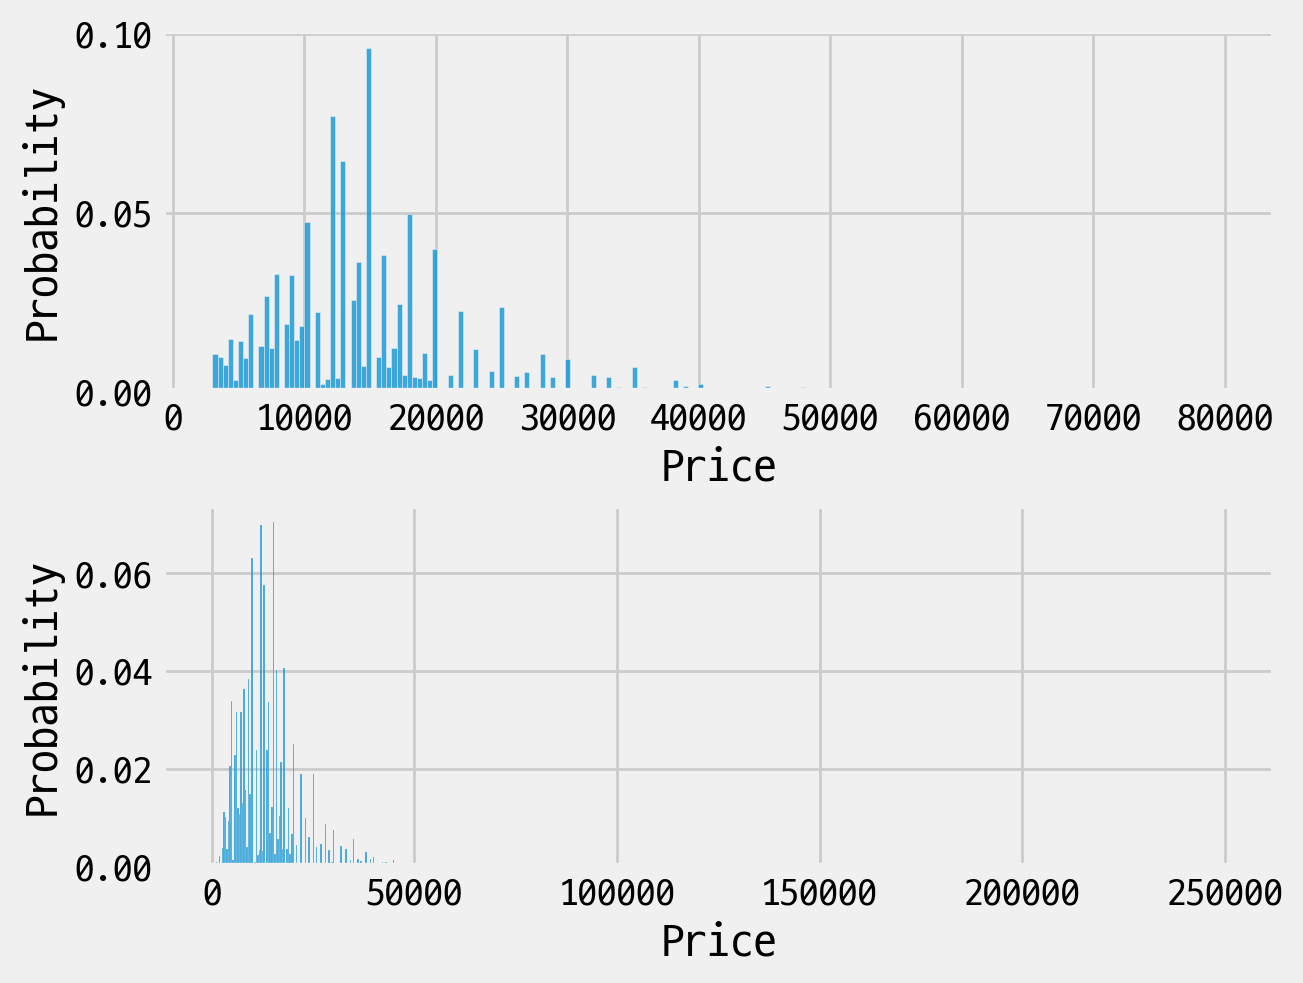

In [32]:
x_sample = pd.concat(sampled.values())
fig,ax = plt.subplots(2,1)
sns.histplot(x_sample,x='Price',ax=ax[0],stat='probability')
sns.histplot(df,x='Price',ax=ax[1],stat='probability')

print(len(x_sample)/len(df))
np.sum(x_sample['Price']>40000)

In [33]:
sliced2= statify_df(x_sample,cols)

ths_config2 = {
    'q_up' : 1-0.02,
    'q_lw' : 0.03,
    'ths_up' : 50000 ,
    'ths_lw' : 3000,
}

ths_dict2 = make_ths_dict(sliced2,**ths_config2)
slice_dict2 = dict() 

for key,ele in sliced2.items():
    cond = (ele['Price'] <= ths_dict2[key]['up']) & (ele['Price']>= ths_dict2[key]['lw'])
    slice_dict2[key] = ele[cond]

  0%|          | 0/620 [00:00<?, ?it/s]

<Axes: >

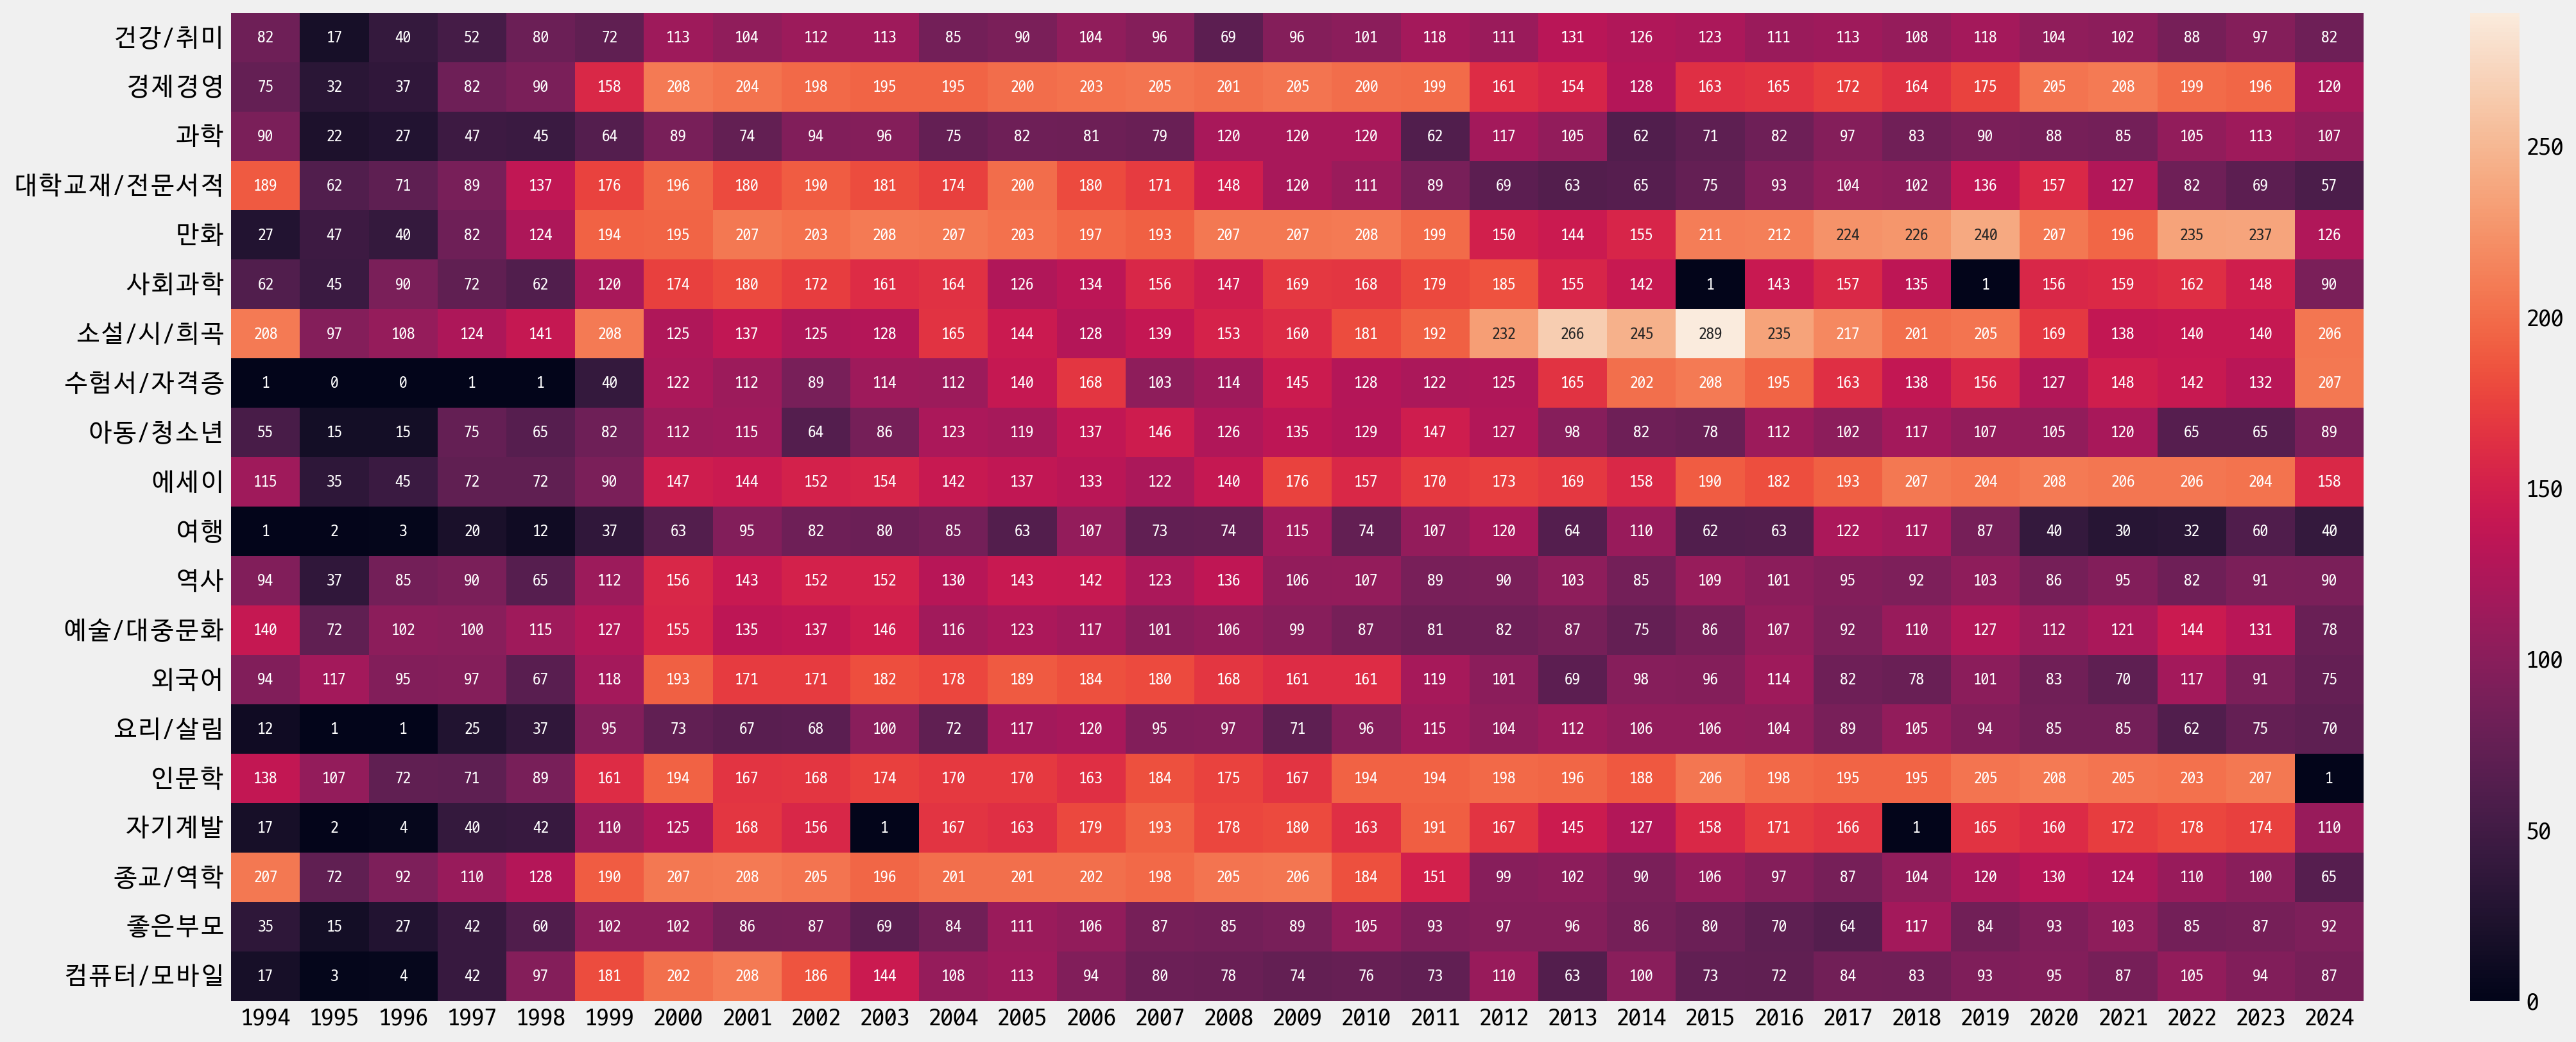

In [34]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))
for key,ele in sliced2.items():
    rslt[key[0]][key[1]] = len(ele)
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

<Axes: >

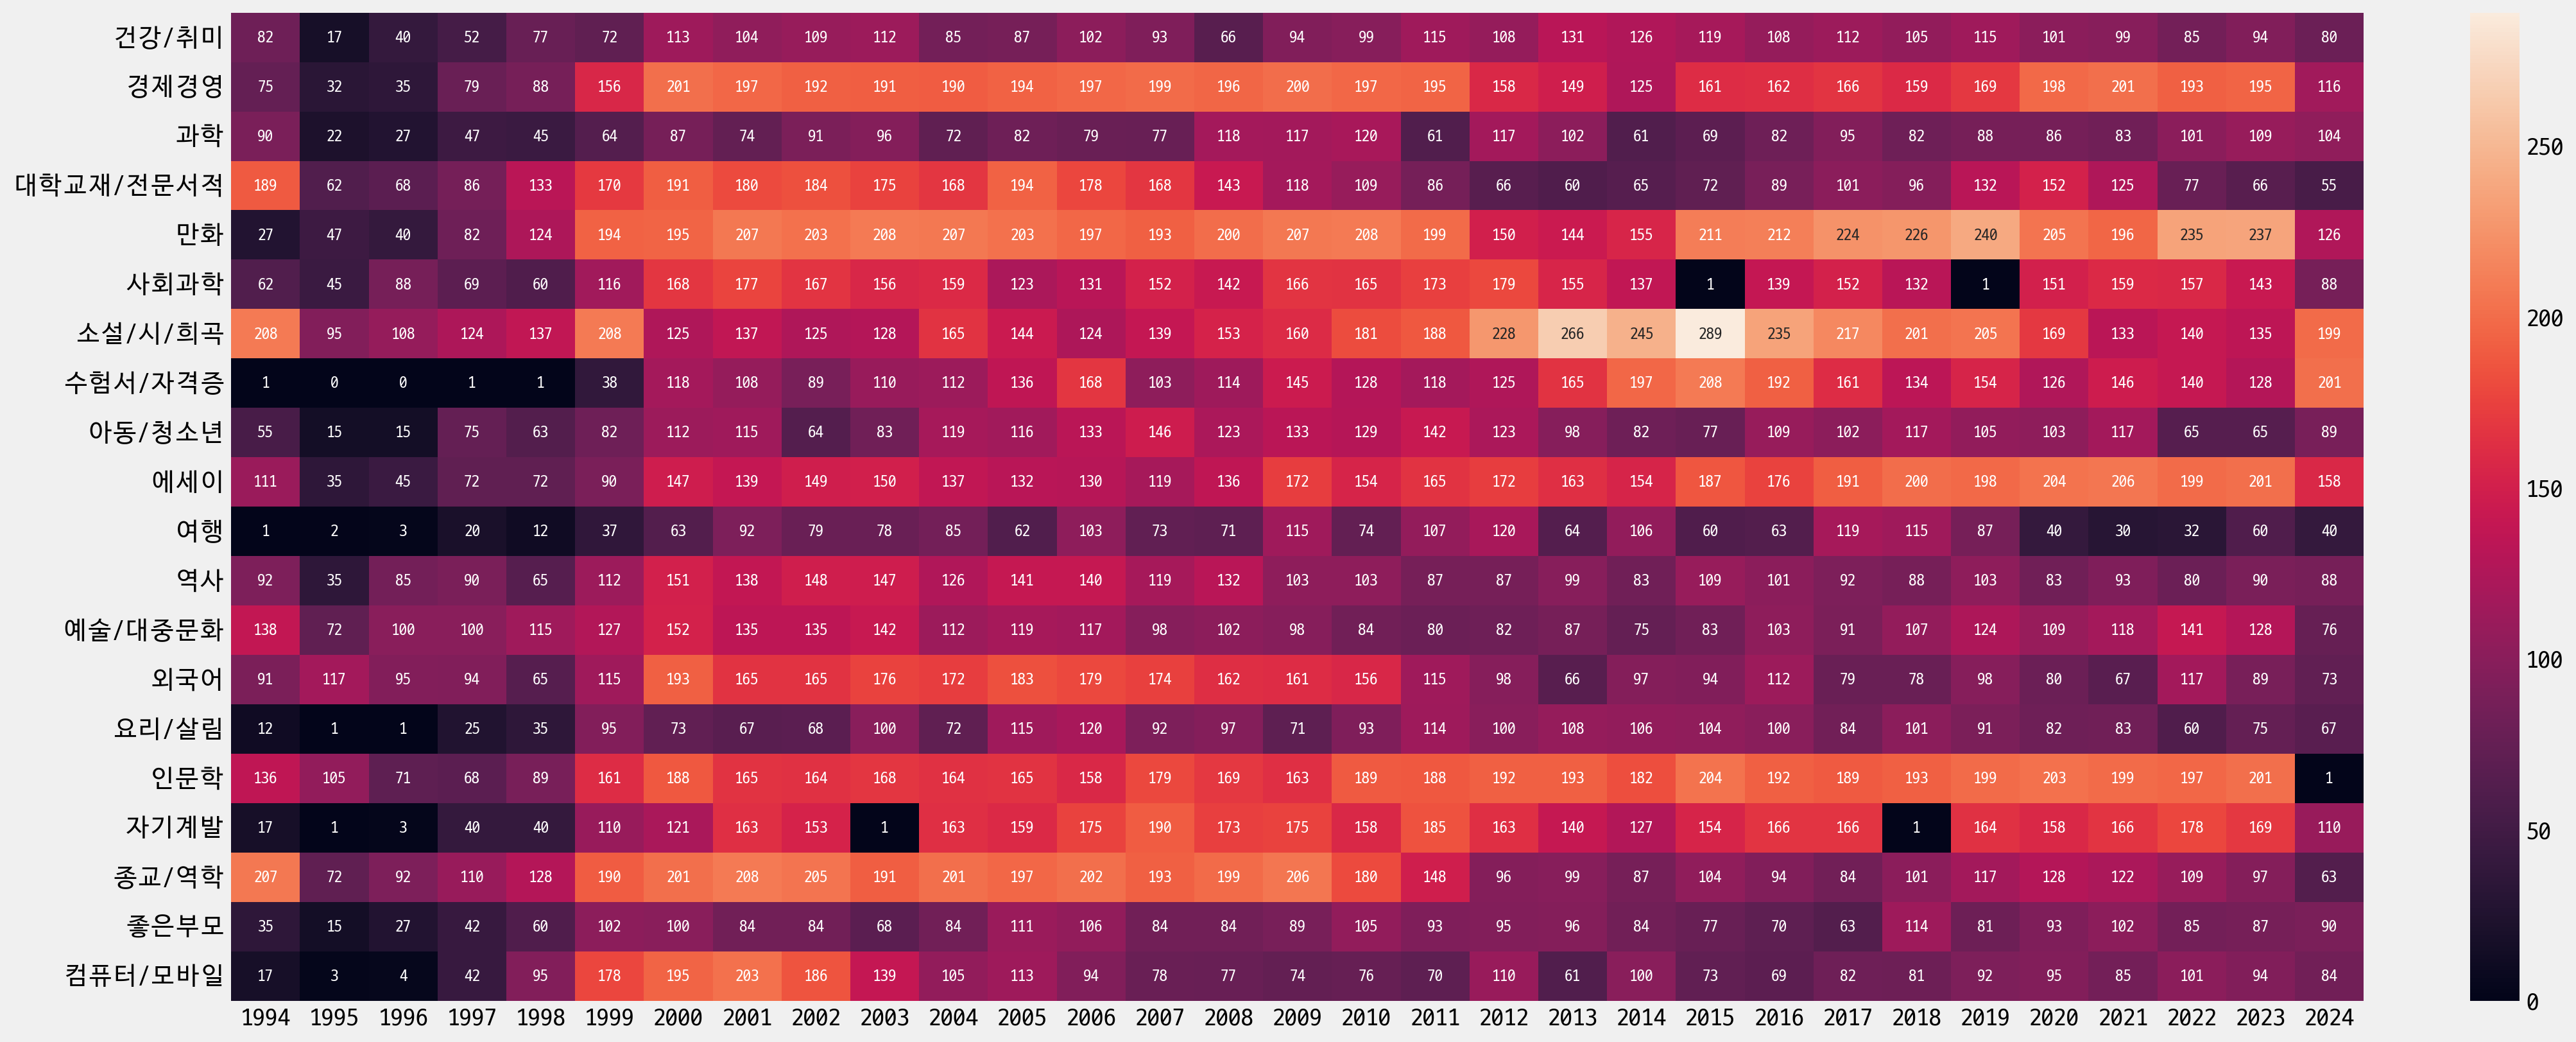

In [35]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict2.items():
    rslt[key[0]][key[1]] = len(ele)
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

0.9678177453175174
0.7575846594880418
0.7440816864028201
37
23


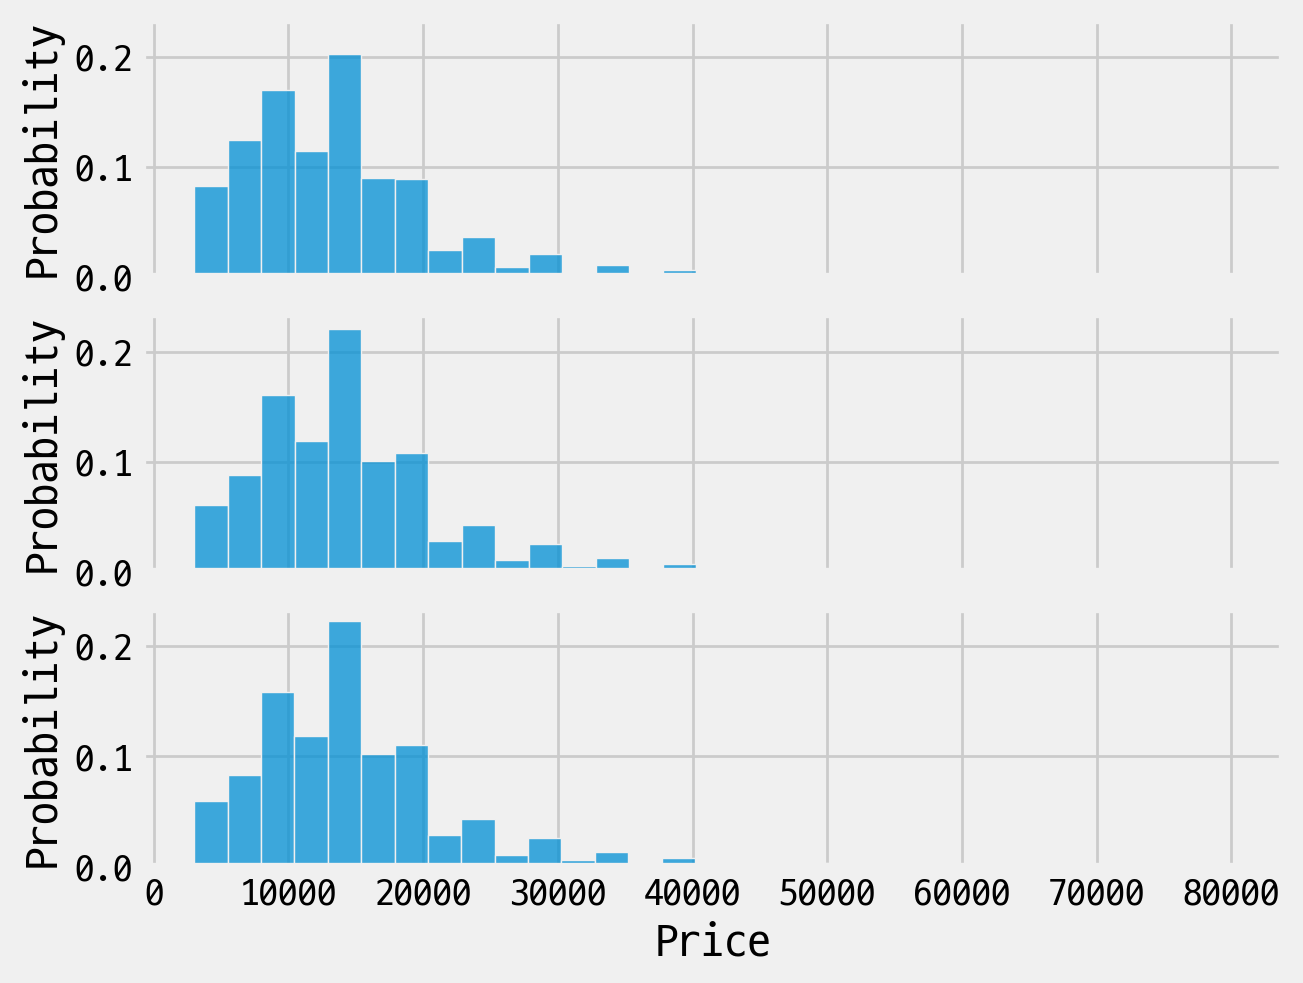

In [36]:
x_sample0 = pd.concat(slice_dict.values())
x_sample1 = pd.concat(sampled.values())
x_sample2 = pd.concat(slice_dict2.values())
fig,ax = plt.subplots(3,1,sharex=True,sharey=True)
sns.histplot(x_sample0,x='Price',ax=ax[0],stat='probability',binwidth=2500)
sns.histplot(x_sample1,x='Price',ax=ax[1],stat='probability',binwidth=2500)
sns.histplot(x_sample2,x='Price',ax=ax[2],stat='probability',binwidth=2500)

print(len(x_sample0)/len(df))
print(len(x_sample1)/len(df))
print(len(x_sample2)/len(df))
print(np.sum(x_sample['Price']>50000))
print(np.sum(x_sample2['Price']>50000))

0.7575846594880418
0.7440816864028201
37
23


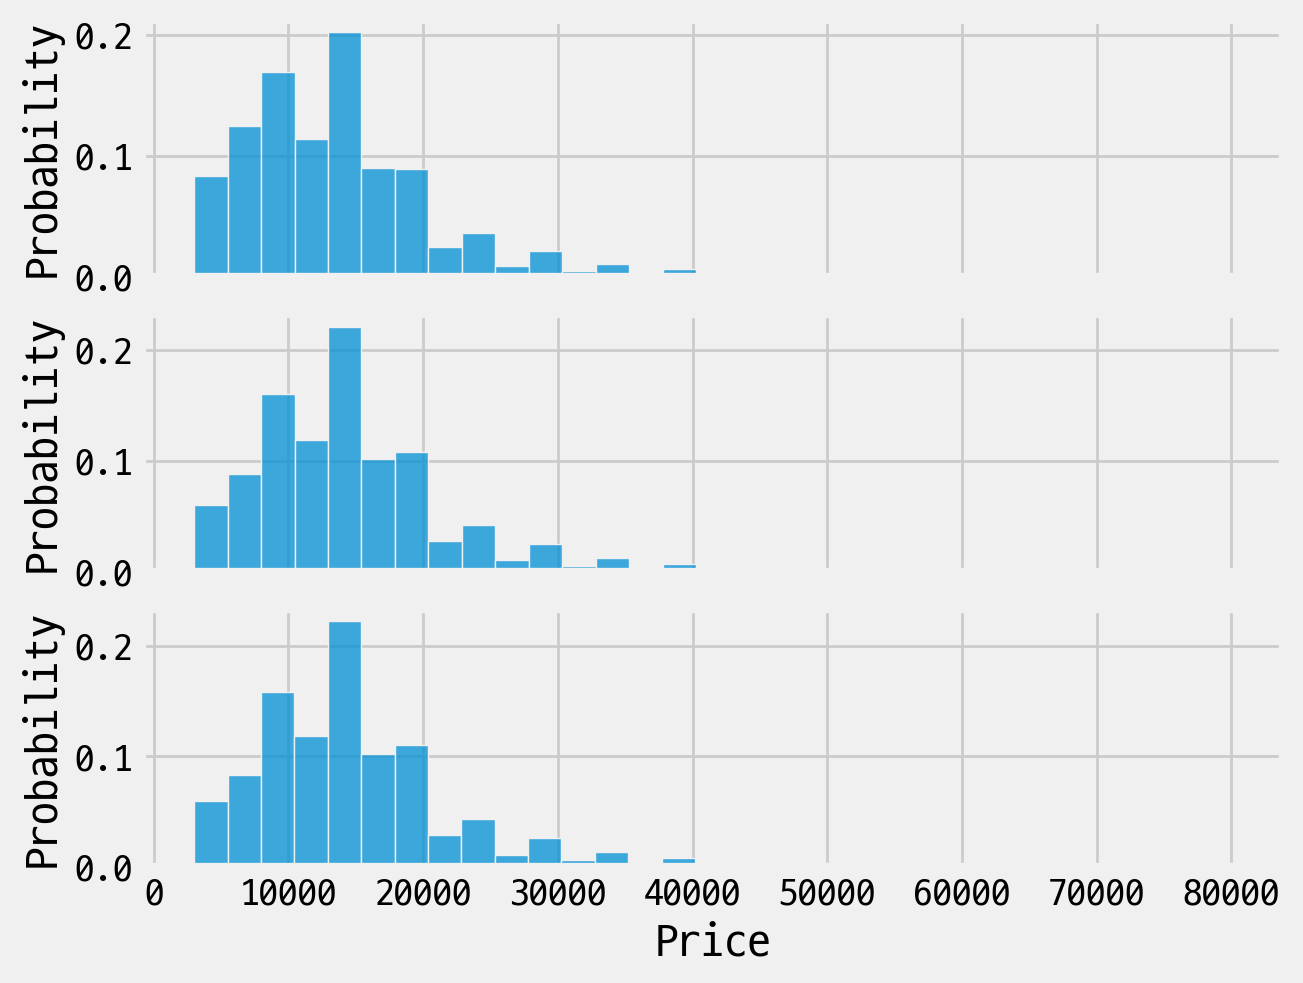

In [37]:
x_sample0 = pd.concat(slice_dict.values())
x_sample1 = pd.concat(sampled.values())
x_sample2 = pd.concat(slice_dict2.values())
fig,ax = plt.subplots(3,1,sharex=True)
sns.histplot(x_sample0,x='Price',ax=ax[0],stat='probability',binwidth=2500)
sns.histplot(x_sample1,x='Price',ax=ax[1],stat='probability',binwidth=2500)
sns.histplot(x_sample2,x='Price',ax=ax[2],stat='probability',binwidth=2500)

print(len(x_sample1)/len(df))
print(len(x_sample2)/len(df))
print(np.sum(x_sample['Price']>50000))
print(np.sum(x_sample2['Price']>50000))

In [37]:
len(x_sample0),len(x_sample2)

(95542, 73455)

|    |    0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    17 |    18 |    19 |    20 |    21 |    22 |    23 |    24 |    25 |
|---:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 | 2500 |  5000 |  7500 | 10000 | 12500 | 15000 | 17500 | 20000 | 22500 | 25000 | 27500 | 30000 | 32500 | 35000 | 37500 | 40000 | 42500 | 45000 | 47500 | 50000 | 52500 | 55000 | 57500 | 60000 | 65000 | 80000 |
|  1 | 5555 | 12646 | 13459 | 14209 | 13534 | 14863 |  6798 |  4833 |  1730 |  2720 |  1346 |  1235 |   520 |   819 |   470 |   295 |   115 |   163 |   139 |    69 |     5 |    13 |     2 |     2 |     1 |     1 |
|    |    0 |    1 |    2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    1

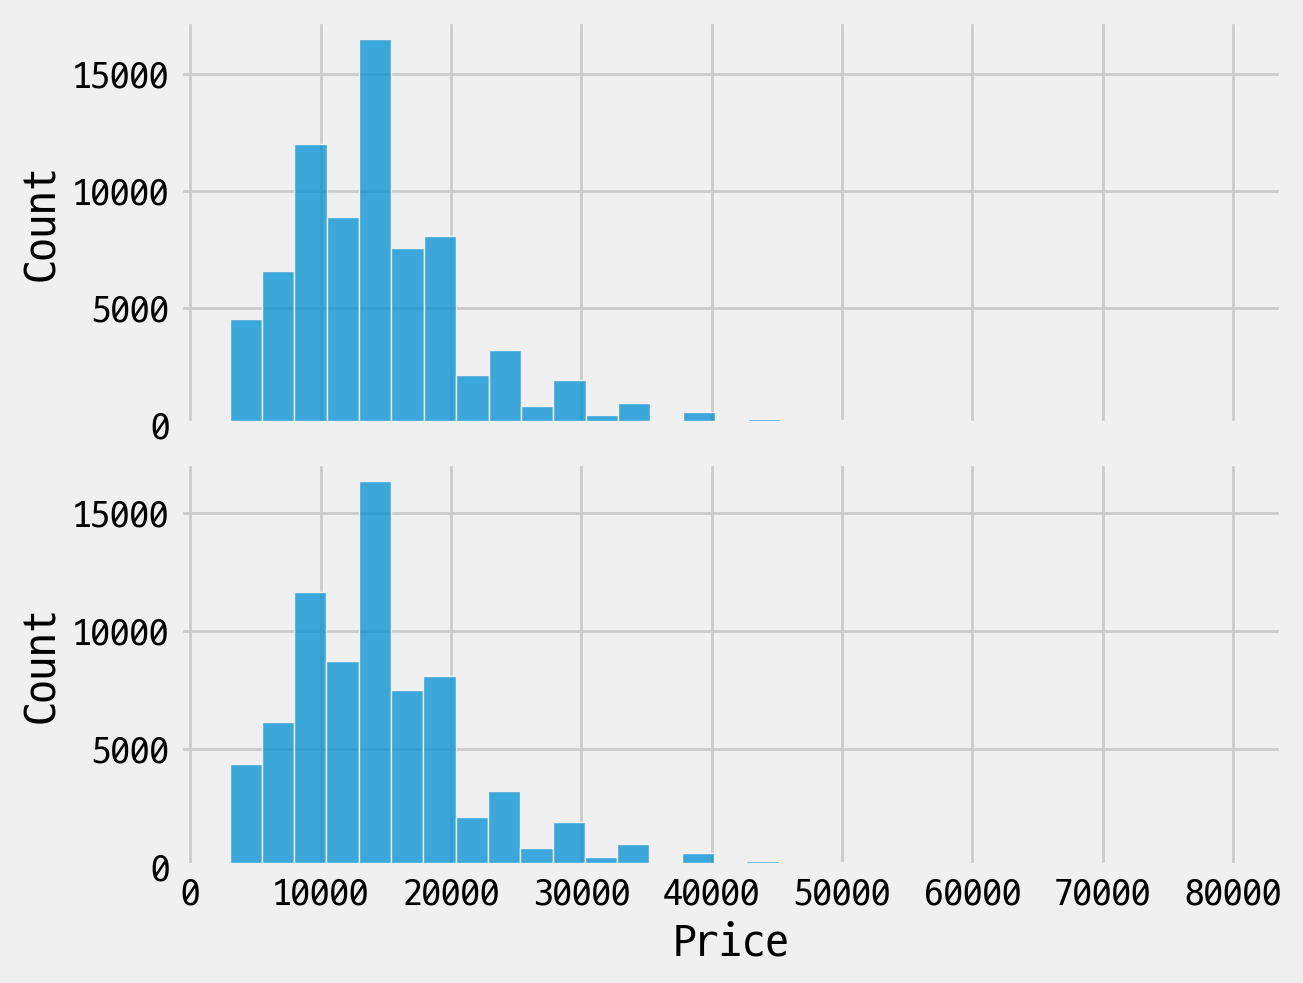

In [39]:
fig,ax2 = plt.subplots(2,1,sharex=True)
sns.histplot(x_sample1,x='Price',ax=ax2[0],binwidth=2500)
sns.histplot(x_sample2,x='Price',ax=ax2[1],binwidth=2500)

print(pd.DataFrame(np.unique((x_sample0['Price']//2500)*2500,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample1['Price']//2500)*2500,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample2['Price']//2500)*2500,return_counts=True)).to_markdown())

|    |    0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    17 |    18 |    19 |    20 |    21 |    22 |    23 |    24 |    25 |
|---:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 | 2500 |  5000 |  7500 | 10000 | 12500 | 15000 | 17500 | 20000 | 22500 | 25000 | 27500 | 30000 | 32500 | 35000 | 37500 | 40000 | 42500 | 45000 | 47500 | 50000 | 52500 | 55000 | 57500 | 60000 | 65000 | 80000 |
|  1 | 5555 | 12646 | 13459 | 14209 | 13534 | 14863 |  6798 |  4833 |  1730 |  2720 |  1346 |  1235 |   520 |   819 |   470 |   295 |   115 |   163 |   139 |    69 |     5 |    13 |     2 |     2 |     1 |     1 |
|    |    0 |    1 |    2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    1

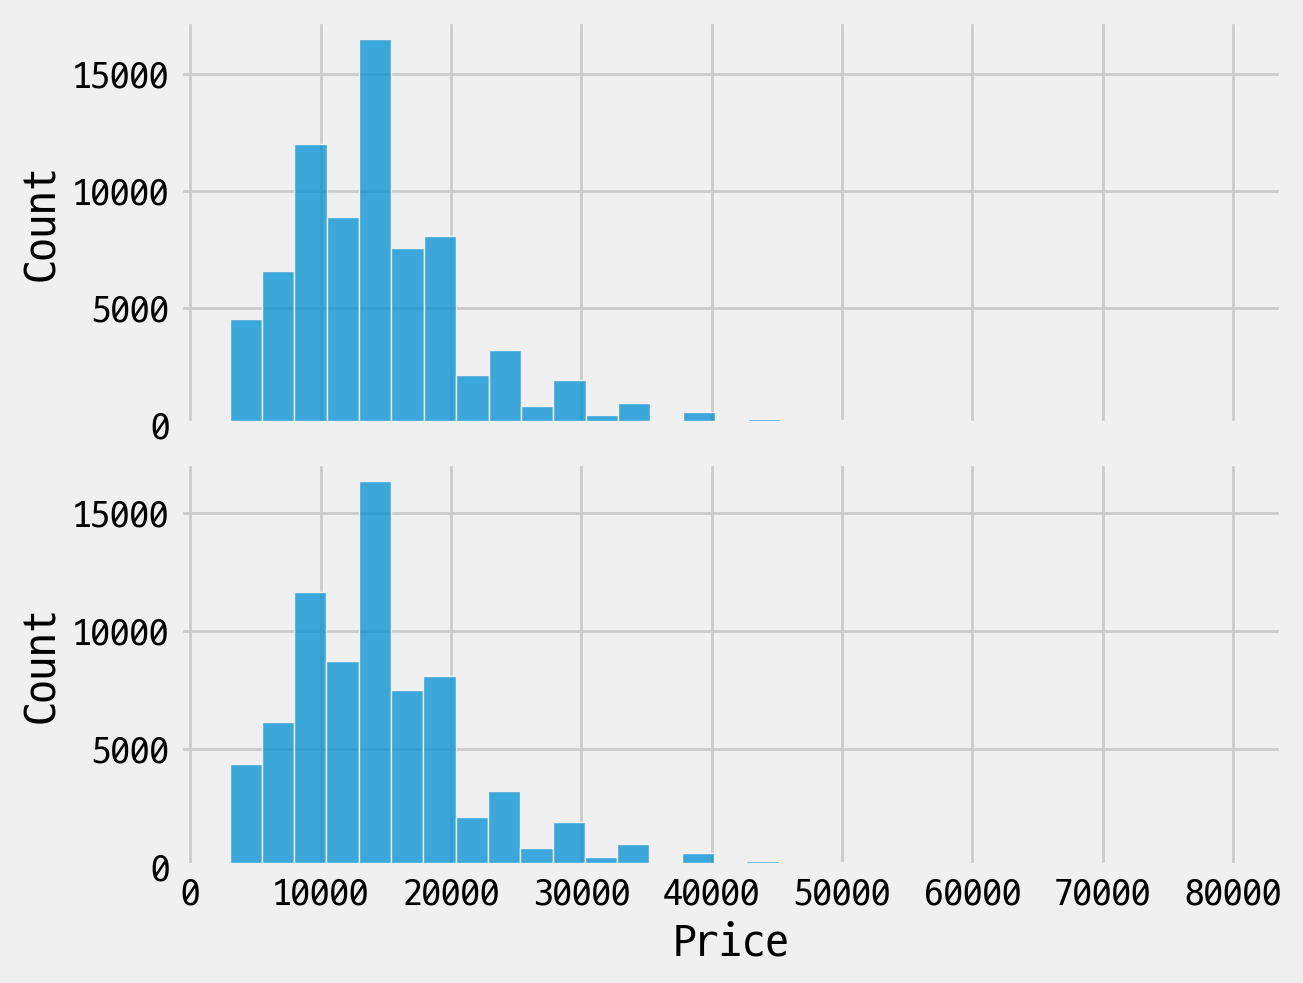

In [40]:
fig,ax2 = plt.subplots(2,1,sharex=True)
sns.histplot(x_sample1,x='Price',ax=ax2[0],binwidth=2500)
sns.histplot(x_sample2,x='Price',ax=ax2[1],binwidth=2500)

print(pd.DataFrame(np.unique((x_sample0['Price']//2500)*2500,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample1['Price']//2500)*2500,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample2['Price']//2500)*2500,return_counts=True)).to_markdown())

|    |    0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |
|---:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 |    0 |  5000 | 10000 | 15000 | 20000 | 25000 | 30000 | 35000 | 40000 | 45000 | 50000 | 55000 | 60000 | 65000 | 80000 |
|  1 | 5555 | 26105 | 27743 | 21661 |  6563 |  4066 |  1755 |  1289 |   410 |   302 |    74 |    15 |     2 |     1 |     1 |
|    |    0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |
|---:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 |    0 |  5000 | 10000 | 15000 | 20000 | 25000 | 30000 | 35000 | 40000 | 45000 | 50000 | 55000 | 60000 | 65000 | 80000 |
|  1 | 3447 | 16101 | 22678 | 19515 |  5942 |  3732 |  1529 |  1093 |   353 |   298 |    76 |    18 |     3 |     2 | 

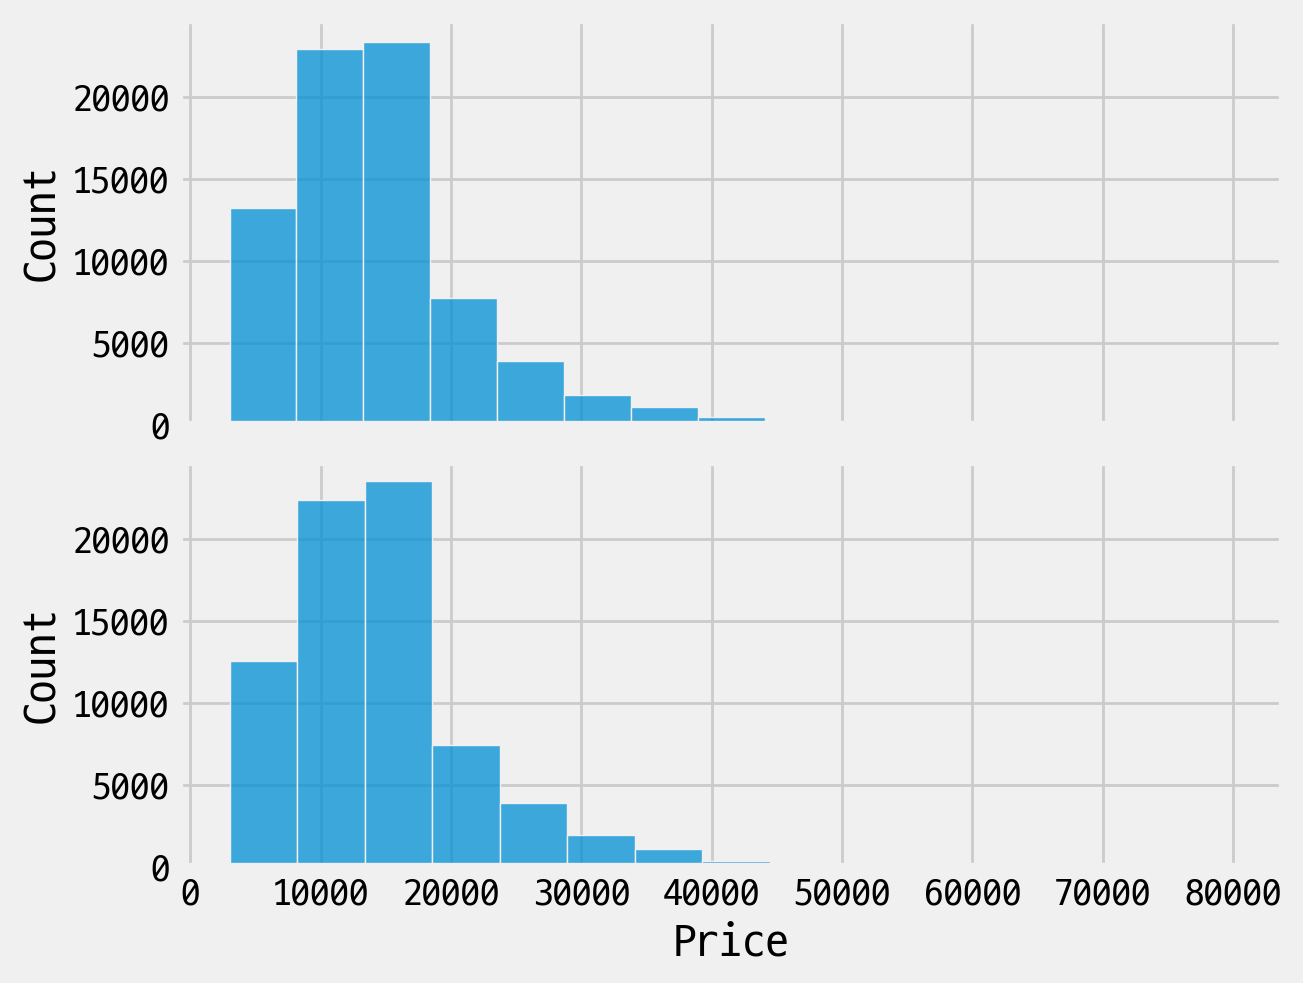

In [41]:
fig,ax2 = plt.subplots(2,1,sharex=True,sharey=True)
sns.histplot(x_sample1,x='Price',ax=ax2[0],binwidth=5000)
sns.histplot(x_sample2,x='Price',ax=ax2[1],binwidth=5000)

print(pd.DataFrame(np.unique((x_sample0['Price']//5000)*5000,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample1['Price']//5000)*5000,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample2['Price']//5000)*5000,return_counts=True)).to_markdown())

|    |    0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |
|---:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 |    0 |  5000 | 10000 | 15000 | 20000 | 25000 | 30000 | 35000 | 40000 | 45000 | 50000 | 55000 | 60000 | 65000 | 80000 |
|  1 | 5555 | 26105 | 27743 | 21661 |  6563 |  4066 |  1755 |  1289 |   410 |   302 |    74 |    15 |     2 |     1 |     1 |
|    |    0 |    1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |
|---:|-----:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 |    0 | 5000 | 10000 | 15000 | 20000 | 25000 | 30000 | 35000 | 40000 | 45000 | 50000 | 55000 | 60000 | 65000 |
|  1 | 1368 | 6446 |  9169 |  7901 |  2421 |  1507 |   608 |   442 |   116 |   114 |    32 |     7 |     2 |     1 |
|    |    0 |    1 |     2 |

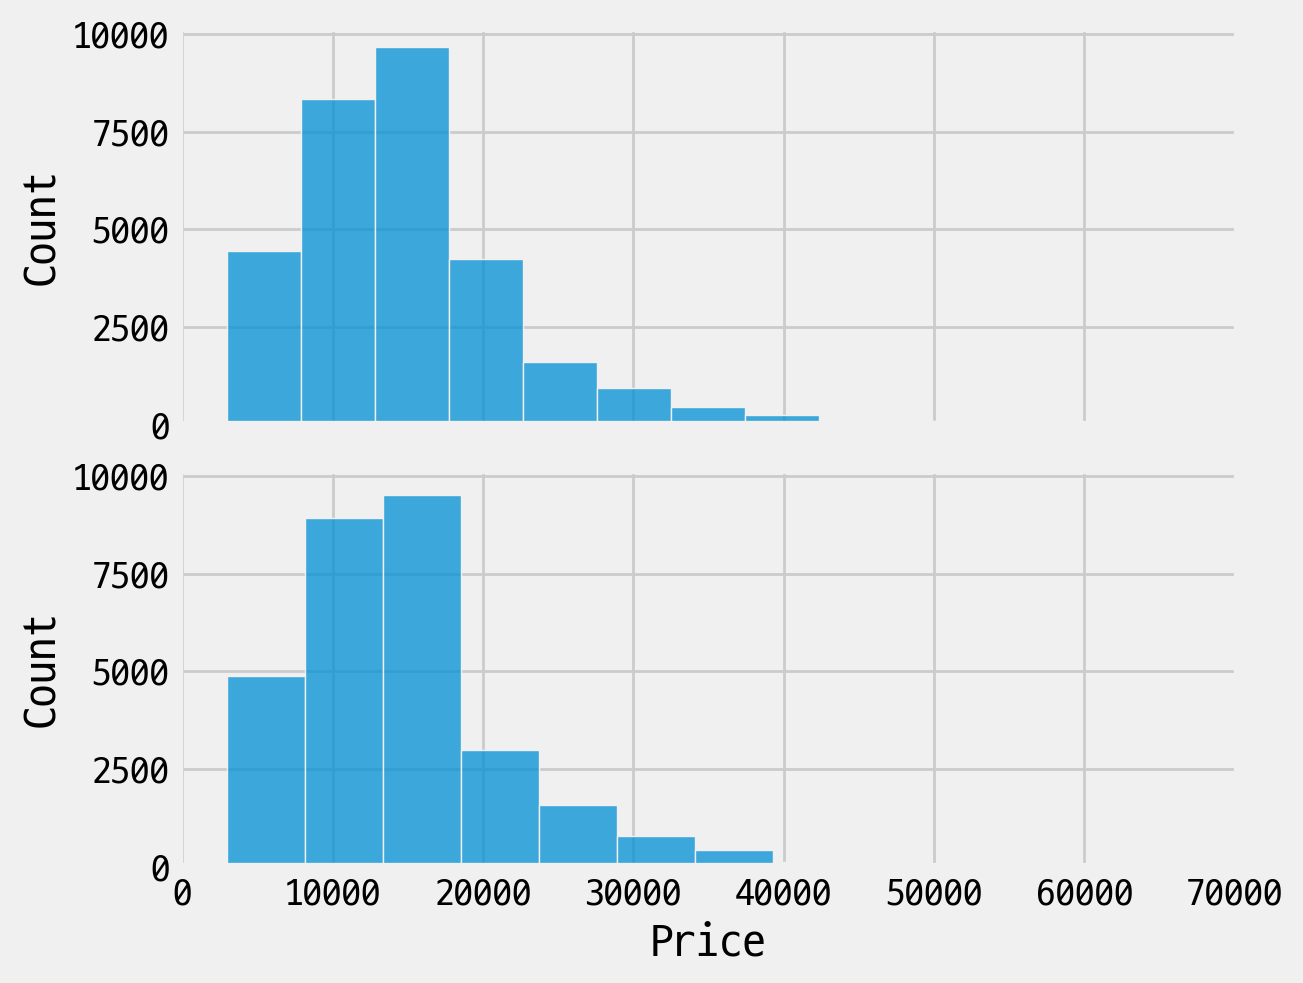

In [54]:
fig,ax2 = plt.subplots(2,1,sharex=True,sharey=True)
sns.histplot(x_sample1,x='Price',ax=ax2[0],binwidth=5000)
sns.histplot(x_sample2,x='Price',ax=ax2[1],binwidth=5000)

print(pd.DataFrame(np.unique((x_sample0['Price']//5000)*5000,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample1['Price']//5000)*5000,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample2['Price']//5000)*5000,return_counts=True)).to_markdown())

In [38]:
from konlpy.tag import Mecab
from tensorflow.keras.preprocessing.sequence import pad_sequences

2025-05-20 19:02:41.081484: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-20 19:02:41.643987: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 19:02:41.771617: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-05-20 19:02:41.771667: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

In [39]:
col_x = [c for c in x_sample2.columns if c not in ['Price']]
X_trn, y_trn = x_sample2[col_x].copy(),x_sample2['Price'].copy()
sampled_dict={
    'trn':{'X':X_trn,'y':y_trn},
    'vld': filtered['vld'].copy(),
    'tst': filtered['tst'].copy()
}

In [40]:
X_trn.columns

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category', 'year'],
      dtype='object')

In [41]:
mecab = Mecab()
tokenizer_basic = lambda x : mecab.morphs(x)
#cut_date = lambda x : [x[:2],x[2:4],x[4:6],x[6:]]
#apply tokenizer
cols_vec = ['Category','BName','BName_sub']
cols_freq = ['Author','Publshr']

for mode, data in sampled_dict.items():
    bookinfo = data['X']
    for col in cols_vec:
        bookinfo[col] = bookinfo[col].fillna('').apply(tokenizer_basic)
    #bookinfo['Pdate'] = bookinfo['Pdate'].astype(str).apply(cut_date)
    bookinfo[['Author_mul','year']] = bookinfo[['Author_mul','year']].astype(int).astype(str)
    data_dict[mode]['X'] = bookinfo

In [42]:
#아래 ths 는 EDA 결과 제가 자의적으로 정한 내용
bookinfo = sampled_dict['trn']['X']
ths_author = int(np.round(len(bookinfo)/500)*75)
ths_publshr = int(np.round(len(bookinfo)/500)*5)

map_author_encode = make_author_encode_map(bookinfo[['Author','SalesPoint']],ths_author)
map_publshr_encode = make_publshr_encode_map(bookinfo['Publshr'],ths_publshr)

encode_maps = {
    'Author' : lambda x : encode_tokens(map_author_encode,x,oov=False),
    'Publshr' : lambda x : encode_tokens(map_publshr_encode,x,oov=False),
}

In [43]:
#apply tokenizer
cols_freq = ['Author','Publshr']
for mode,data in sampled_dict.items():
    for col,maps in tqdm(encode_maps.items()):
        data['X'][col] = data['X'][col].map(maps).astype(str)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

In [44]:
ranks = ['Author','Publshr']

#oov_val = '.'
oov_val_dict = {
    'Author' : str(len(map_author_encode)+1),
    'Publshr' : str(len(map_publshr_encode)+1),
}

for mode,sample in tqdm(sampled_dict.items()):
    for col in ranks:
        cond = sample['X'][col] == '0'
        sample['X'].loc[cond,col] = oov_val_dict[col]

  0%|          | 0/3 [00:00<?, ?it/s]

In [45]:
cols_tknz= ['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'year','Category']
book_tknzed = bookinfo[cols_tknz].to_dict('series')

cols_num = list(filter(lambda x : x not in cols_vec, cols_tknz))
number_slicer = lambda x : [x[max(0,i-2):i] for i in range(len(x),0,-2)[::-1]]
for col in cols_num:
    print(col)
    book_tknzed[col] = book_tknzed[col].apply(number_slicer)

Author
Publshr
Author_mul
year


In [46]:
tkn_vals=[]
for col in cols_num:
    tkn_vals.append(np.array(list(itertools.chain(*book_tknzed[col].values))))
for col in cols_vec:
    temp = pd.Series(list(itertools.chain(*book_tknzed[col].values)))
    cond = ~(pd.to_numeric(temp,errors='coerce')).isna()
    temp[cond] = temp[cond].apply(number_slicer)
    temp[~cond] = temp[~cond].apply(lambda x :[x])
    tkn_vals.append(np.array(list(itertools.chain(*temp.values))))

tokens = np.concatenate(tkn_vals,axis=0)
tokens_ds = pd.Series(tokens)
cond_numeric = ~(pd.to_numeric(tokens_ds,errors='coerce')).isna()

tokens_num = tokens[cond_numeric]
tokens_str = tokens[~cond_numeric]

print(len(tokens_num),len(tokens_str))
print(len(np.unique(tokens_num)),len(np.unique(tokens_str)))

517192 581882
110 25926


In [47]:
temp,cnt = np.unique(tokens_num,return_counts=True)
temp2 = np.apply_along_axis(lambda x : [(len(n),cnt[i]) for i,n in enumerate(x)],axis=0,arr=temp)
np.sum(temp2[:,1][temp2[:,0] < 3])/np.sum(cnt)

1.0

In [48]:
#tkns_num = 17594
#tkns_num = 21135
#tkns_num = 23639
#tkns_num = 11000
tkns_num = 25926
token_freq_str = np.unique(tokens_str,return_counts=True)
token_freq_num = np.unique(tokens_num,return_counts=True)
map_token_encode_str = make_encoding_by_freq(token_freq_str,size_feat=tkns_num)
map_token_encode_num = make_encoding_by_freq(token_freq_num)

In [49]:
np.mean(token_freq_str[1] < 2), np.sum(token_freq_str[1]>1)

(0.40604026845637586, 15399)

In [50]:
token_freq_num

(array(['0', '00', '01', '02', '03', '04', '05', '06', '07', '08', '09',
        '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
        '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
        '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39',
        '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49',
        '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59',
        '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69',
        '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79',
        '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89',
        '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99'],
       dtype='<U15'),
 array([43998,  4719,  3501,  3322,  3175,  3278,  3270,  3316,  3235,
         3289,  3339, 46425,  5635,  4650,  4571,  4420,  4201,  4492,
        64225,  3702,  3673, 12520, 11531, 72835,  3751,  3534,  3480,
         3098,   878,   815,   747

In [51]:
map_token_encode_num_placed = dict()
for key,val in map_token_encode_num.items():
    if key == '[PAD]' : continue
    map_token_encode_num_placed[key] = val+tkns_num

map_token_encode_total = dict(map_token_encode_str,**map_token_encode_num_placed)
encode_1line =lambda x: list(map(lambda y : encode_tokens(map_token_encode_total,y),x))

BName 31
BName_sub 34
Author 2
Publshr 2
Author_mul 1
year 2
Category 5


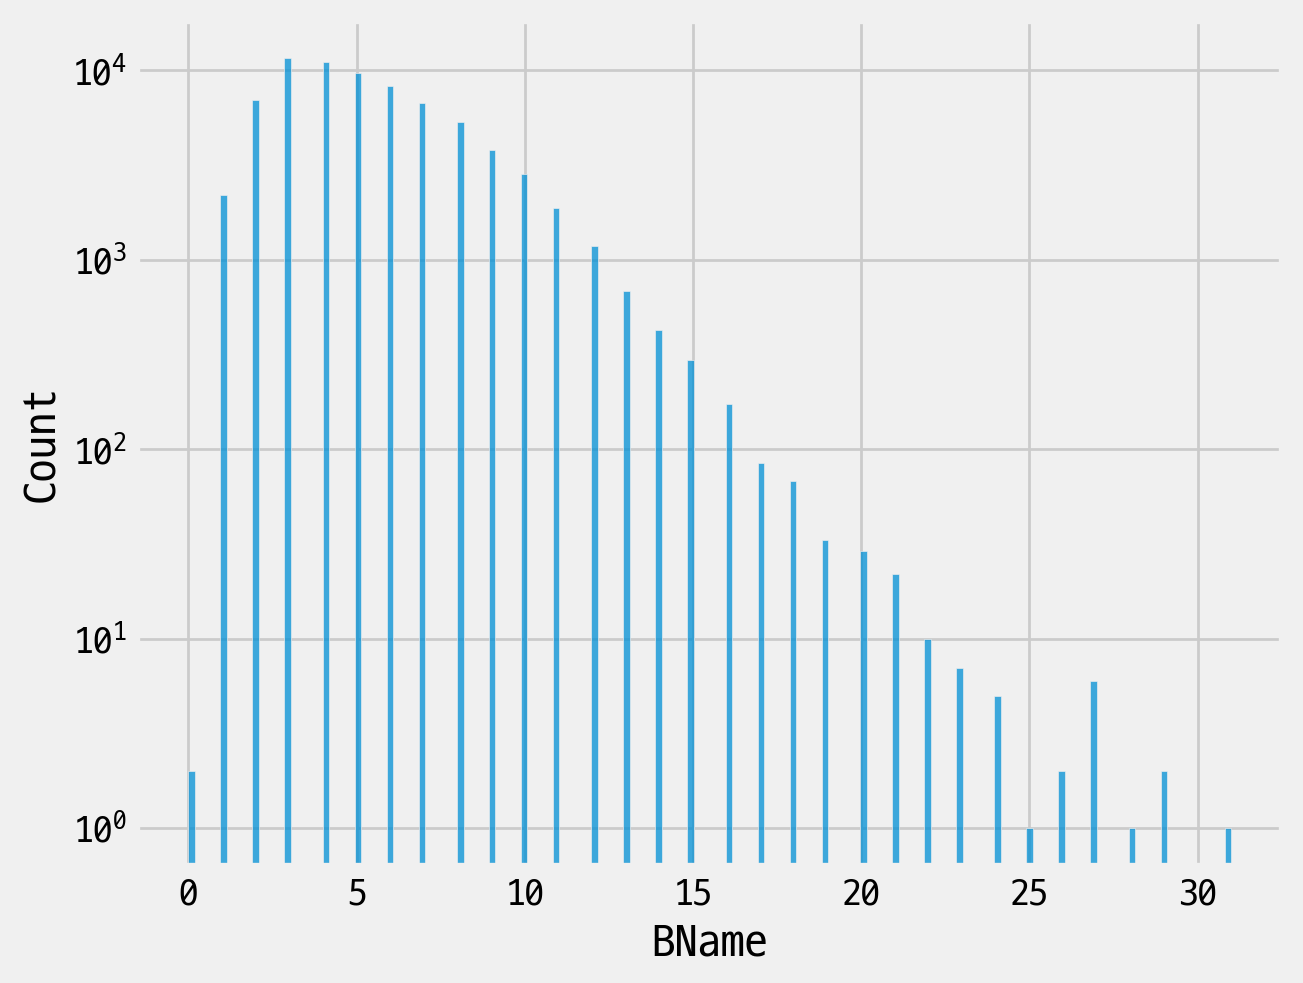

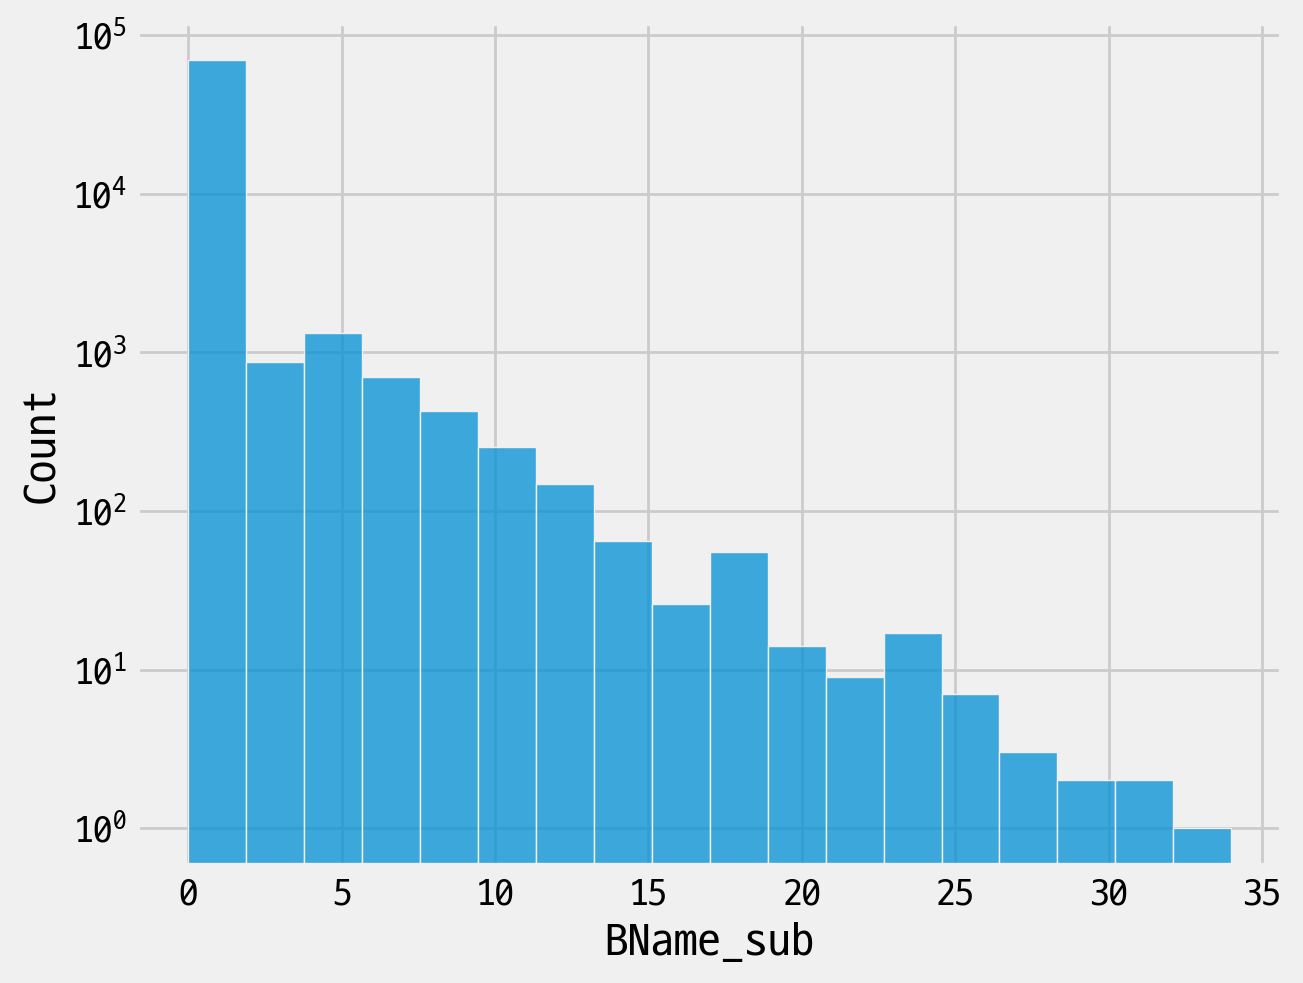

In [52]:
for k,v in book_tknzed.items():
    temp = v.apply(lambda x : len(x))
    print(k,temp.max())
    if 'BName' in k:
        fig,ax = plt.subplots()
        sns.histplot(temp,ax=ax)
        ax.set_yscale('log')

In [53]:
maxlens={
    'Category' : 5,
    'BName' : 29,
    'BName_sub' : 23,
    'year' : 2,
    'Publshr' : 2,
    'Author' : 2,
    'Author_mul' : 1
}
x_cols = ['BName', 'BName_sub', 'Author',
   'Author_mul', 'Publshr', 'year','Category']

book_cols = ['BName', 'BName_sub', 'Author', 'Author_mul', 'Publshr', 'year',
       'RglPrice', 'SalesPoint', 'Category']
xcols_scalar = list(filter(lambda x : x not in maxlens.keys(),x_cols)) 

In [54]:
from module_aladin.nlp import erase_space
def find_split_num(text):
    pat = r'[\s\d]+'
    mtch_list = list(re.finditer(pat,text))
    c,rslt=0,list()
    for m in mtch_list:
        if c < m.start() : rslt.append((text[c:m.start()],0))
        rslt.append((erase_space(text[m.start():m.end()]),1))
        c=m.end()
    else :
        if c < len(text): rslt.append((text[c:len(text)],0))
    return rslt


def number_splitter(data):
    rslt = list()
    for txt in data:
        temp = find_split_num(txt)
        if not temp :rslt.append(temp)
        else :
            intrmd=list()
            for ele in temp:
                if ele[1] == 0 : intrmd.append(ele[0])
                else : intrmd.extend(number_slicer(ele[0]))
            rslt.extend(intrmd)
    return rslt        

In [55]:
#encode X
X_encoded=dict()
for mode,sample in tqdm(sampled_dict.items()):
    X_mode = sample['X'].copy()
    #padding and encoding
    encoded = pd.DataFrame(index=X_mode.index) 
    for col in tqdm(x_cols):
        if col in cols_num:
            X_mode[col] = X_mode[col].apply(number_slicer)
        if col in cols_vec:
            X_mode[col] = X_mode[col].apply(number_splitter)
        
        padded = pad_sequences(X_mode[col],padding='post',
                                   maxlen=maxlens[col],
                                   value='[PAD]',dtype=object)
        encoded[col] = list(np.apply_along_axis(encode_1line,0,padded))

    concat_tknzed =np.apply_along_axis(np.hstack,1,encoded[list(maxlens.keys())].values)
    x_scalar = encoded[xcols_scalar].values
    X = np.hstack((concat_tknzed,x_scalar))
    X_encoded[mode] = X    

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

In [56]:
display(np.sum(np.isnan(X_encoded['trn'].astype(np.float64))))
display(np.sum(np.isnan(X_encoded['vld'].astype(np.float64))))
display(np.sum(np.isnan(X_encoded['tst'].astype(np.float64))))

0

0

0

In [57]:
print(len(np.unique(X_encoded['trn'])))
print(len(map_token_encode_total))
print(np.max(X_encoded['trn']))
print(np.min(X_encoded['trn']))

26033
26037
26036.0
0.0


In [58]:
#courpus_size_in = 17750
courpus_size_in = 26039 #23753 #11115 #21250
max_len = 64

In [59]:
sampled_dict['trn']['X'].iloc[4310]

BName         [Power, Bunka, Japanese, 1]
BName_sub                              []
Author                               1629
Publshr                               124
Author_mul                              0
Pdate                 1997-11-26 00:00:00
SalesPoint                             38
Category                            [외국어]
year                                 1997
Name: 17244, dtype: object

In [60]:
X_encoded['trn'][4310]

array([   30.,     0.,     0.,     0.,     0.,  1990.,  3173.,  2221.,
       25930.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0., 25934., 25967., 25930., 25961., 25928., 25929., 25931.])

In [61]:
config_pre = {
    'base_config' : base_config,
    'ths_config1' : ths_config1,
    'sample_config' : sample_config,
    'ths_config2' : ths_config2
}

X_coded = {
    mode : data
    for mode, data in X_encoded.items()
}
X_coded['info'] ={
    'corpus_size' : courpus_size_in,
    'max_len' : max_len,
    'config_pre' : config_pre,
    'encode':{
        'decode_map' :{
            'map' : { v:k for k,v in map_token_encode_total.items()}
        },
        'columns' : maxlens,
        'oov_val' :    oov_val_dict,
    }       
}

### encode y

In [62]:
def remain_k_digits(n,k):
  r = np.floor(np.log10(n))
  temp = np.round(n/(10**r),k-1)
  temp = np.round(temp*(10**r),0)
  return (temp).astype(int)

def make_val_keys(data):
  lbnd = data.min()//1000
  ubnd = data.max()//1000
  temp = np.unique(remain_k_digits(np.arange(lbnd,ubnd+2),2)*1000)
  return temp[1:]

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0
    return map_token[x] if x in map_token else oov_val

def encode_to_2digit(data,keys):
  val = remain_k_digits(data,2)
  val[val < keys.min()] = keys.min()
  val[val > keys.max()] = keys.max()

  cond = val < 10000
  val[cond] = remain_k_digits(val[cond],1)
  encode_map= {
      k : i for i,k in enumerate(keys)
  }
  encode_1line = lambda y : list(map(lambda x : encode_tokens(encode_map,x),y))
  return np.apply_along_axis(encode_1line,0,val), encode_map


In [63]:
data = data_dict['trn']['y']
val_keys = make_val_keys(data)
encoded,encode_map = encode_to_2digit(data,val_keys)

/tmp/ipykernel_124354/3157627052.py:2: RuntimeWarning: divide by zero encountered in log10
  r = np.floor(np.log10(n))
/tmp/ipykernel_124354/3157627052.py:3: RuntimeWarning: invalid value encountered in divide
  temp = np.round(n/(10**r),k-1)
/tmp/ipykernel_124354/3157627052.py:5: RuntimeWarning: invalid value encountered in cast
  return (temp).astype(int)


In [64]:
print(len(data))
print(pd.DataFrame(np.unique(encoded,return_counts=True)).to_markdown())

98835
|    |   0 |   1 |    2 |    3 |    4 |    5 |    6 |    7 |    8 |    9 |   10 |   11 |   12 |   13 |   14 |   15 |   16 |   17 |   18 |   19 |   20 |   21 |   22 |   23 |   24 |   25 |   26 |   27 |   28 |   29 |   30 |   31 |   32 |   33 |   34 |   35 |   36 |   37 |   38 |   39 |   40 |   41 |   42 |   43 |   44 |   45 |   46 |   47 |   48 |   49 |   50 |   51 |   52 |   53 |   54 |   55 |   56 |   57 |   58 |   59 |   60 |   61 |   62 |   63 |   64 |   65 |   66 |   67 |   68 |   69 |   70 |   71 |   72 |   73 |   74 |   75 |   76 |   77 |   78 |   79 |   80 |   81 |   82 |   83 |   84 |   85 |   86 |   87 |   88 |   89 |   90 |   91 |   92 |   93 |   94 |   95 |
|---:|----:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----

In [65]:
decode_map = {v:k for k,v in encode_map.items()}

In [66]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [67]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in sampled_dict.items():
    coded,_ = encode_to_2digit(sample['y'],val_keys)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': coded, }

corpus_size_out=len(encode_map)
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'encode':{'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    },
    'corpus_size':  corpus_size_out,
}

    

In [68]:
for mode,sample in y_coded.items():
    if mode == 'info' : continue
    temp = sample['coded']
    print(mode,temp.min(),temp.max())

trn 2 59
vld 0 114
tst 0 112


### encode log y

In [191]:
# encode y

def encode_log(x):
    str_x = f'{np.log10(x):.4f}'.split('.')
    temp = [str_x[0]]+list(str_x[1])
    return ['[SOS]']+temp+['[EOS]']

tkn_lists = data_dict['trn']['y'].apply(encode_log).values
#y_tkn_vals = np.array(list(itertools.chain(*tkn_lists)))
y_tkn_vals = np.concatenate(tkn_lists,axis=0)
y_tkn_freq = np.unique(y_tkn_vals,return_counts=True)
map_y_tkns = make_encoding_by_freq(y_tkn_freq)
encode_y_1line = lambda x : list(map(lambda y : encode_tokens(map_y_tkns,y,oov=False),x))

display(y_tkn_freq)
display(map_y_tkns)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '[EOS]', '[SOS]'],
       dtype='<U5'),
 array([ 54637,  65032,  45711,  68786, 106223,  26834,  22204,  43099,
         15587,  46062,  98835,  98835]))

{'4': 1,
 '[EOS]': 2,
 '[SOS]': 3,
 '3': 4,
 '1': 5,
 '0': 6,
 '9': 7,
 '2': 8,
 '7': 9,
 '5': 10,
 '6': 11,
 '8': 12,
 '[PAD]': 0}

In [197]:
decode_map = {v:k for k,v in map_y_tkns.items()}
sen_tkns = ['[SOS]','[EOS]','[PAD]',]
sentkns_dict = {
    tkn : map_y_tkns[tkn]
    for tkn in sen_tkns
}

In [53]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [55]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    temp = sample['y'].apply(encode_log)
    padded = pad_sequences(temp,padding='post',
                                   maxlen=y_max_len,
                                   value='[PAD]',dtype=object)
    intrmd = np.apply_along_axis(encode_y_1line,0,padded)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': intrmd.astype(np.int32), }

corpus_size_out=13
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    'corpus_size':  corpus_size_out,
    'tkn': sentkns_dict ,
    'max_len': y_max_len,
}

    

In [69]:
RSLT_DIR

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/'

In [70]:
ls {RSLT_DIR}/model_input

BERT_cls-single.v1.0_st-0_X_info.pkl    encodedXy.v1.5_st-0_y_trn.pkl
BERT_cls-single.v1.0_st-0_X_trn.pkl     encodedXy.v1.5_st-0_y_tst.pkl
BERT_cls-single.v1.0_st-0_X_tst.pkl     encodedXy.v1.5_st-0_y_vld.pkl
BERT_cls-single.v1.0_st-0_X_vld.pkl     encodedXy.v2.0_st-0_X_trn.pkl
BERT_cls-single.v1.0_st-0_y_info.pkl    encodedXy.v2.0_st-0_X_tst.pkl
BERT_cls-single.v1.0_st-0_y_trn.pkl     encodedXy.v2.0_st-0_X_vld.pkl
BERT_cls-single.v1.0_st-0_y_tst.pkl     encodedXy.v2.0_st-0_y_info.pkl
BERT_cls-single.v1.0_st-0_y_vld.pkl     encodedXy.v2.0_st-0_y_trn.pkl
BERT_cls-single.v1.5_st-0_X_info.pkl    encodedXy.v2.0_st-0_y_tst.pkl
BERT_cls-single.v1.5_st-0_X_trn.pkl     encodedXy.v2.0_st-0_y_vld.pkl
BERT_cls-single.v1.5_st-0_X_tst.pkl     encodedXy.v2.5_st-0_X_info.pkl
BERT_cls-single.v1.5_st-0_X_vld.pkl     encodedXy.v2.5_st-0_X_trn.pkl
BERT_cls-single.v1.5_st-0_y_info.pkl    encodedXy.v2.5_st-0_X_tst.pkl
BERT_cls-single.v1.5_st-0_y_trn.pkl     encodedXy.v2.5_st-0_X_vld.pkl
BERT_cls-single.v1

In [71]:
data_type = 'sampled_trn_arr'
strat=0
ver='1.d'
dir_path = os.path.join(RSLT_DIR,'model_input')
for mode, x_scaled in X_coded.items():
    save_pkl(dir_path,'{}.v{}_st-{}_X_{}.pkl'.format(data_type,ver,strat,mode),x_scaled)
for mode,data in y_coded.items(): 
    save_pkl(dir_path,'{}.v{}_st-{}_y_{}.pkl'.format(data_type,ver,strat,mode),data)

In [119]:
cand = list(filter(lambda x : 'info' in x ,os.listdir(dir_path)))
cand = sorted(cand)

temp = list(map(lambda x: load_pkl(os.path.join(dir_path,x)),cand))
[(n,x.keys()) for n,x in zip(cand,temp)]

[('BERT_cls-single.v1.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.0_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_cls-single.v1.5_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.5_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_cls-single.v1.a_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.a_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_sampled_trn.v1.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_sampled_trn.v1.0_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_sampled_trn.v1.5_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len', 'config_pre', 'config_enc'])),
 ('BERT_sampled_trn.v1.5_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_sampled_trn.v2.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_sampled_trn.v2.0_st-0_y_info.pkl',
  dic

#### numpy,torch examples

In [164]:
np.triu(np.ones((1,7,7)),k=1)==0

array([[[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [ True,  True,  True, False, False, False, False],
        [ True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]]])

In [58]:
import torch
torch.zeros(3,3,3)

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

In [166]:
a = np.triu(np.ones((2,7,3)),k=-1)


a = torch.LongTensor(a)
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]])

In [167]:
a[:,-1,:] = 2

a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]]])

In [175]:
a[:,-2,:] = torch.LongTensor([[1,3,2],[9,8,7]])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [177]:
a[:,-3] = torch.LongTensor([5,7,8])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [178]:
a.max(dim=-1)

torch.return_types.max(
values=tensor([[1, 1, 1, 1, 8, 3, 2],
        [1, 1, 1, 1, 8, 9, 2]]),
indices=tensor([[0, 0, 1, 2, 2, 1, 0],
        [0, 0, 1, 2, 2, 0, 0]]))

In [180]:
a[:,:,-2] = torch.LongTensor([2,5,6,3,1,9,6])
a

tensor([[[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [1, 9, 2],
         [2, 6, 2]],

        [[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [9, 9, 7],
         [2, 6, 2]]])

In [183]:
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6, 10]]])

In [186]:
a[-1,-1,-1] = 7
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6,  7]]])

In [187]:
a[:,-1,:].max(dim=-1)

torch.return_types.max(
values=tensor([10,  7]),
indices=tensor([2, 2]))